# Hoja de trabajo #2 — Transformers y mecanismos de atención

**CC3092 · Deep Learning y Sistemas Inteligentes** — Universidad del Valle de Guatemala

**Nicolás Concuá** · Guatemala, octubre de 2026

Repositorio: https://github.com/nicoCT04/Hoja_trabajo_2_DL

Este notebook recorre el camino **RNN → atención → Transformer**: primero la investigación (secciones 2 a 4), luego
un **ejercicio a mano** de *scaled dot-product attention*, una **implementación desde cero** de atención y multi-head
attention, los experimentos de **escalamiento** (por qué se divide entre √d_k) y de **costo computacional** (O(n²)),
las **verificaciones** contra PyTorch y, por último, el **análisis de atención en BERT y GPT-2**: mapas de calor por
cabeza, correferencia de «it», matriz causal y *attention sinks*, entropía por capa, ablación de cabezas y una prueba
de si la atención explica las predicciones.

## 0. Configuración del entorno

**Hardware:** Apple M4 Pro (backend **MPS** de PyTorch para el experimento de costo; BERT y GPT-2 se corren en CPU,
que para oraciones cortas es suficiente y es determinista). El código usa CUDA automáticamente si existe.

In [1]:
# Descomenta para instalar dependencias (p. ej. en Colab):
# !pip install torch transformers matplotlib pandas numpy bertviz

In [2]:
import os, math, time, random, platform, warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import transformers
from transformers import AutoTokenizer, AutoModel, BertForMaskedLM, GPT2LMHeadModel
transformers.logging.set_verbosity_error()
transformers.logging.disable_progress_bar()       # sin barras de «Loading weights» en las salidas

pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 30)
pd.set_option('display.precision', 4)

# Semilla global para reproducibilidad.
SEED = 42
def fijar_semilla(s=SEED):
    random.seed(s); np.random.seed(s); torch.manual_seed(s)
fijar_semilla()

# Rutas robustas: funciona si se corre desde la raíz del repo o desde notebook/.
RAIZ = os.path.abspath('..') if os.path.basename(os.getcwd()) == 'notebook' else os.getcwd()
REPORTS = os.path.join(RAIZ, 'reports')
os.makedirs(REPORTS, exist_ok=True)

# Dispositivo para el benchmark de costo (los modelos preentrenados van en CPU).
if torch.cuda.is_available():
    DEV = torch.device('cuda')
elif torch.backends.mps.is_available():
    DEV = torch.device('mps')
else:
    DEV = torch.device('cpu')

plt.rcParams.update({'figure.dpi': 110, 'savefig.dpi': 150, 'font.size': 9, 'axes.grid': True, 'grid.alpha': 0.3})

def guardar(fig, nombre):
    """Guarda la figura en reports/ para reutilizarla en el informe."""
    fig.savefig(os.path.join(REPORTS, nombre), bbox_inches='tight')

print('Python', platform.python_version(), '| torch', torch.__version__, '| transformers', transformers.__version__)
print('Dispositivo para el benchmark:', DEV, '|', platform.processor() or platform.machine())

Python 3.12.14 | torch 2.14.1 | transformers 5.18.0
Dispositivo para el benchmark: mps | arm


## 2. Investigación: de las RNN a la atención

**Cuello de botella del seq2seq con RNN.** En el modelo encoder-decoder [4] el encoder lee toda la oración y la
resume en **un solo vector de tamaño fijo** (su último estado oculto), y el decoder genera la traducción solo a partir
de ese vector. La capacidad del vector no crece con la entrada: con oraciones largas hay que comprimir más
información en el mismo espacio y lo del inicio se va «borrando» al pasar por muchos pasos de recurrencia. Cho et al.
mostraron que el BLEU cae fuertemente a partir de ~20 palabras. **Bahdanau** [2] elimina el resumen único: el encoder
(bidireccional) conserva **todos** sus estados h_1…h_T y en cada paso i el decoder calcula un puntaje
e_ij = vᵀ tanh(W s_{i−1} + U h_j) con cada estado, los normaliza con softmax (α_ij) y usa el contexto
c_i = Σ_j α_ij h_j. Cada palabra de salida «mira» directamente las palabras de entrada relevantes (alineamiento
suave), así que la información ya no tiene que sobrevivir a todo el recorrido del encoder.

**Aditiva (Bahdanau) vs. multiplicativa (Luong).** La aditiva compara consulta y llave con una pequeña MLP
(vᵀ tanh(W s + U h)); la multiplicativa [3] usa el producto punto s·h (o sᵀW h, «general»). Ambas tienen complejidad
teórica parecida, pero la de producto punto es **mucho más eficiente en hardware moderno**: todos los puntajes de
una secuencia salen de **una sola multiplicación de matrices** QKᵀ, que las GPU/TPU ejecutan con kernels GEMM
altamente optimizados (tensor cores), mientras que la aditiva necesita materializar un tensor n × m × d_a, aplicar
tanh elemento a elemento y proyectar con v, con más memoria y operaciones menos optimizadas [1]. Su desventaja es que
para d_k grande los productos punto crecen en magnitud — de ahí el escalamiento √d_k del Transformer (sección 3).

**Consulta, llave y valor como diccionario «suave».** Un diccionario normal busca la llave **idéntica** a la
consulta y devuelve **un** valor. La atención compara la consulta con **todas** las llaves (similitud q·k),
convierte las similitudes en pesos que suman 1 (softmax) y devuelve el **promedio ponderado de todos los valores**:
una búsqueda difusa y diferenciable, entrenable por gradiente. En **self-attention** Q, K y V salen de la **misma**
secuencia mediante tres proyecciones aprendidas (Q = XW_Q, K = XW_K, V = XW_V): cada token pregunta a todos los
demás. En **cross-attention** (encoder-decoder) las **consultas vienen del decoder** y las **llaves y valores de la
salida del encoder**: cada token que se genera consulta la oración de origen.

**Qué limitaciones de las RNN elimina el Transformer.**
- *Procesamiento secuencial:* una RNN necesita O(n) pasos que dependen del anterior (h_t requiere h_{t−1}), así que
  no se paraleliza a lo largo de la secuencia. La self-attention procesa todas las posiciones a la vez con
  multiplicaciones de matrices: O(1) operaciones secuenciales por capa [1].
- *Dependencias de largo alcance:* entre dos tokens a distancia k una RNN tiene un camino de longitud O(k); en la
  self-attention cualquier par está conectado **directamente** (camino O(1)).
- *Desvanecimiento del gradiente:* el gradiente en una RNN se multiplica por el Jacobiano de cada paso y tiende a
  desvanecerse o explotar con la distancia [5]; en el Transformer el gradiente entre dos posiciones atraviesa una
  sola atención por capa y las conexiones residuales, sin cadena de n pasos.
- El precio: costo **cuadrático** en n y la pérdida de la noción de orden, que hay que reinyectar con codificación
  posicional.

## 3. Investigación: la arquitectura Transformer

**Scaled dot-product attention.** Attention(Q, K, V) = softmax(QKᵀ / √d_k) V. Si los componentes de q y k son
independientes con media 0 y varianza 1, q·k = Σ_{i=1}^{d_k} q_i k_i es una suma de d_k términos con media 0 y
varianza Var(q_i k_i) = E[q_i²]E[k_i²] = 1, así que **Var(q·k) = d_k** (desviación √d_k). Con d_k = 64 los puntajes
tienen desviación 8: la softmax queda **saturada** (casi one-hot, toda la masa en el máximo) y su Jacobiano
diag(p) − ppᵀ tiende a cero, así que los **gradientes se desvanecen** y el entrenamiento se estanca. Dividir entre
√d_k devuelve los puntajes a varianza 1 independientemente de la dimensión [1]. (Se verifica empíricamente en 5.3.)

**Multi-head attention.** En lugar de una atención con d_model dimensiones se usan h cabezas de d_k = d_model/h,
cada una con sus propias proyecciones, y se concatenan y proyectan con W_O. Se gana que **cada cabeza puede atender
a un patrón distinto** (sintaxis, posición, correferencia) en su propio subespacio; con una sola cabeza todas las
relaciones se mezclarían en un único promedio ponderado. **El número de parámetros no cambia**: las h matrices
d_model × d_k de cada proyección suman d_model × d_model, así que en total siguen siendo 4·d_model² (+ sesgos), y el
costo en FLOPs es similar. Lo que sí crece es la memoria de las matrices de atención (h matrices n × n).

**Codificación posicional.** La self-attention es **equivariante a permutaciones**: si se reordenan los tokens de
entrada, las salidas se reordenan igual (la suma ponderada no depende del orden), así que «el perro mordió al
hombre» y «el hombre mordió al perro» serían indistinguibles. El artículo suma a cada embedding
PE(pos, 2i) = sin(pos / 10000^{2i/d}), PE(pos, 2i+1) = cos(pos / 10000^{2i/d}): sinusoides con longitudes de onda en
progresión geométrica; PE(pos + k) es una transformación lineal de PE(pos), lo que facilita atender por posición
relativa, y no tiene parámetros. Los **embeddings posicionales aprendidos** (BERT, GPT-2) son una tabla entrenada por
posición: igual de buenos en la práctica [1], pero limitados a la longitud máxima vista (512 / 1024) y sin
extrapolación. **RoPE** [7] no suma nada a la entrada: **rota** pares de componentes de q y k en cada capa con un
ángulo proporcional a la posición, de modo que q_m·k_n depende solo de la distancia m − n (posición relativa); es el
estándar en LLaMA, Mistral, etc., y se puede extender a contextos más largos reescalando las frecuencias.

**Bloque completo.** Cada subcapa (atención y feed-forward) va envuelta en una **conexión residual** (x + F(x)), que
da un camino directo al gradiente y permite apilar muchas capas, y en **LayerNorm**, que normaliza cada token
(media 0, varianza 1 sobre sus features) para estabilizar la escala de las activaciones. La **feed-forward por
posición** FFN(x) = W_2 · ReLU(W_1 x + b_1) + b_2 (d_ff = 4·d_model) se aplica igual a cada token por separado: la
atención mezcla información **entre** tokens y la FFN la transforma **dentro** de cada token (ahí está ~2/3 de los
parámetros). **Post-LN** (original): x ← LN(x + F(x)); la normalización queda en el camino residual y, como mostraron
Xiong et al. [6], los gradientes cerca de la salida son grandes al inicio, por lo que necesita *warm-up* del learning
rate y es inestable en modelos profundos. **Pre-LN**: x ← x + F(LN(x)) (más una LN final); el camino residual
queda limpio, el entrenamiento es estable sin warm-up y escala a cientos de capas, por eso lo usan GPT-2/3, LLaMA y
casi todos los modelos actuales (a veces con ligera pérdida de calidad final frente a un Post-LN bien entrenado).

**Complejidad.** Calcular QKᵀ cuesta **O(n² · d)** en tiempo y la matriz de atención ocupa **O(n²)** de memoria por
cabeza y capa (frente a O(n · d²) de las proyecciones y la FFN): con n grande domina el término cuadrático. Propuestas:
- **FlashAttention** [8]: atención **exacta** calculada por bloques en la SRAM de la GPU, sin materializar la matriz
  n × n; memoria O(n) y 2–4× más rápida. No reduce los FLOPs (siguen siendo O(n²)), recalcula en el backward y
  requiere kernels específicos del hardware.
- **Atención por ventanas / dispersa** (Longformer [9], Mistral): cada token atiende solo a w vecinos (más algunos
  tokens globales): O(n · w). Sacrifica la conexión directa entre tokens lejanos (solo llega apilando capas).
- **Atención lineal** [10] (y Performer, Linformer): reemplaza softmax(QKᵀ) por φ(Q)φ(K)ᵀ y reordena el producto como
  φ(Q)(φ(K)ᵀV): O(n). Es una **aproximación**: pierde la normalización exacta y la nitidez de la softmax, y en la
  práctica suele rendir peor en tareas de recuperación precisa.

## 4. Investigación: atención en PyTorch y Hugging Face [11][12]

| Clase / función | Propósito | Parámetros relevantes |
|---|---|---|
| `F.scaled_dot_product_attention(q, k, v, ...)` | Atención softmax(QKᵀ·scale + máscara)V en un solo kernel; elige automáticamente entre FlashAttention, *memory-efficient* o la implementación matemática. Devuelve **solo la salida**, no los pesos. | `attn_mask`: booleana (**True = sí puede atender**) o flotante que se **suma** a los puntajes; forma broadcastable a (…, L, S). `dropout_p`: dropout sobre los pesos (usar 0.0 en evaluación). `is_causal`: aplica la máscara triangular inferior (no se combina con `attn_mask`). `scale`: factor de escala; por defecto 1/√d_k. |
| `nn.MultiheadAttention(embed_dim, num_heads, ...)` | Módulo completo de multi-head: proyecciones Q, K, V (en `in_proj_weight`), h cabezas de embed_dim/num_heads y proyección de salida `out_proj`. | `embed_dim` (divisible entre `num_heads`); `batch_first` (True → tensores (B, L, E); por defecto (L, B, E)); `kdim`, `vdim`: dimensiones distintas para llaves/valores (cross-attention), crean `q_proj_weight`, `k_proj_weight`, `v_proj_weight` separados. |
| `MultiheadAttention.forward(q, k, v, ...)` | — | `key_padding_mask` (B, S): **True = posición de padding que se ignora**. `attn_mask` (L, S) o (B·h, L, S): booleana con **True = prohibido** (¡al revés que en `F.sdpa`!) o flotante aditiva. `need_weights`: si devuelve los pesos (False permite el kernel rápido). `average_attn_weights`: True → pesos promediados (B, L, S); False → por cabeza (B, h, L, S). |
| `nn.TransformerEncoderLayer(d_model, nhead, ...)` | Un bloque encoder: self-attention + FFN, cada una con residual, dropout y LayerNorm. | `dim_feedforward` (d_ff, por defecto 2048), `dropout` (0.1), `activation`, `batch_first`, `norm_first` (**False = Post-LN** del artículo, **True = Pre-LN**). En el forward: `src_mask`, `src_key_padding_mask`, `is_causal`. |
| `nn.Transformer.generate_square_subsequent_mask(n)` | Máscara causal para que la posición i solo vea j ≤ i. | Devuelve un tensor flotante n × n con **0 en y bajo la diagonal y −inf encima** (se suma a los puntajes). |
| Hugging Face: `output_attentions=True` | Pide al modelo que devuelva los pesos de atención (post-softmax). | En `from_pretrained` o en el forward. `outputs.attentions` es una **tupla con un tensor por capa**, cada uno de forma **(batch, cabezas, n, n)** (12 capas × (1, 12, n, n) en BERT-base y GPT-2). Requiere `attn_implementation="eager"`: los kernels `sdpa`/flash no materializan los pesos. En encoder-decoder hay además `decoder_attentions` y `cross_attentions`. |

## 5. Ejercicios prácticos

### 5.1 Ejercicio a mano: scaled dot-product attention con 3 tokens

Tres tokens con d_k = d_v = 2:

Q = K = [[1, 0], [0, 1], [1, 1]],   V = [[1, 2], [3, 4], [5, 6]]

**Paso 1 — puntajes QKᵀ** (fila i = q_i · k_j):
[[1, 0, 1], [0, 1, 1], [1, 1, 2]]

**Paso 2 — escalar entre √d_k = √2 ≈ 1.4142:**
[[0.7071, 0, 0.7071], [0, 0.7071, 0.7071], [0.7071, 0.7071, 1.4142]]

**Paso 3 — softmax por fila.** e^0.7071 = 2.0281, e^0 = 1, e^1.4142 = 4.1133.
- Fila 1: suma 2.0281 + 1 + 2.0281 = 5.0562 → [0.4011, 0.1978, 0.4011]
- Fila 2: [0.1978, 0.4011, 0.4011]
- Fila 3: suma 2.0281 + 2.0281 + 4.1133 = 8.1695 → [0.2483, 0.2483, 0.5035]

**Paso 4 — salida = A·V** (promedio ponderado de las filas de V):
- Fila 1: 0.4011·[1,2] + 0.1978·[3,4] + 0.4011·[5,6] = [3.0000, 4.0000]
- Fila 2: 0.1978·[1,2] + 0.4011·[3,4] + 0.4011·[5,6] = [3.4067, 4.4067]
- Fila 3: 0.2483·[1,2] + 0.2483·[3,4] + 0.5035·[5,6] = [3.5105, 4.5105]

**Con máscara causal** (el token i solo ve j ≤ i, se pone −∞ encima de la diagonal):
fila 1 = softmax([0.7071]) = [1] → [1, 2]; fila 2 = softmax([0, 0.7071]) = [0.3302, 0.6698] → [2.3395, 3.3395];
fila 3 no cambia (ya ve a todos).

El token 3 (q = [1, 1]) se parece más a k_3 = [1, 1] (producto 2) y por eso le da la mitad de su atención. Abajo se
reproduce cada paso con código.

In [3]:
# Matrices del ejercicio a mano.
Q = torch.tensor([[1., 0.], [0., 1.], [1., 1.]])
K = Q.clone()
V = torch.tensor([[1., 2.], [3., 4.], [5., 6.]])
d_k = Q.shape[-1]

puntajes = Q @ K.T
escalados = puntajes / math.sqrt(d_k)
pesos = torch.softmax(escalados, dim=-1)
salida = pesos @ V
print('Paso 1 - QK^T:\n', puntajes.numpy())
print('Paso 2 - QK^T / sqrt(d_k):\n', escalados.numpy().round(4))
print('Paso 3 - softmax por fila:\n', pesos.numpy().round(4), '\n  (suma por fila:', pesos.sum(-1).numpy(), ')')
print('Paso 4 - salida A V:\n', salida.numpy().round(4))

# Versión causal: -inf encima de la diagonal antes de la softmax.
mascara = torch.triu(torch.ones(3, 3, dtype=torch.bool), diagonal=1)
pesos_c = torch.softmax(escalados.masked_fill(mascara, float('-inf')), dim=-1)
print('\nCausal - pesos:\n', pesos_c.numpy().round(4))
print('Causal - salida:\n', (pesos_c @ V).numpy().round(4))

Paso 1 - QK^T:
 [[1. 0. 1.]
 [0. 1. 1.]
 [1. 1. 2.]]
Paso 2 - QK^T / sqrt(d_k):
 [[0.7071 0.     0.7071]
 [0.     0.7071 0.7071]
 [0.7071 0.7071 1.4142]]
Paso 3 - softmax por fila:
 [[0.4011 0.1978 0.4011]
 [0.1978 0.4011 0.4011]
 [0.2483 0.2483 0.5035]] 
  (suma por fila: [1. 1. 1.] )
Paso 4 - salida A V:
 [[3.     4.    ]
 [3.4067 4.4067]
 [3.5105 4.5105]]

Causal - pesos:
 [[1.     0.     0.    ]
 [0.3302 0.6698 0.    ]
 [0.2483 0.2483 0.5035]]
Causal - salida:
 [[1.     2.    ]
 [2.3395 3.3395]
 [3.5105 4.5105]]


### 5.2 Implementación desde cero: atención y multi-head attention

`atencion` implementa la ecuación del artículo con máscara opcional (convención de `F.scaled_dot_product_attention`:
**True = puede atender**). `MultiHeadPropia` proyecta X a Q, K, V, separa en h cabezas de d_model/h, aplica la
atención en paralelo (un solo `matmul` por lote y cabeza), concatena y proyecta con W_O.

In [4]:
def atencion(q, k, v, mascara=None, causal=False, escala=None):
    """Scaled dot-product attention. q: (..., L, d_k), k: (..., S, d_k), v: (..., S, d_v).
    mascara: booleana broadcastable a (..., L, S); True = el par (i, j) puede atender.
    Devuelve (salida, pesos)."""
    escala = 1 / math.sqrt(q.shape[-1]) if escala is None else escala
    s = (q @ k.transpose(-2, -1)) * escala                       # (..., L, S)
    if causal:
        L, S = s.shape[-2:]
        s = s.masked_fill(torch.triu(torch.ones(L, S, dtype=torch.bool, device=s.device), 1), float('-inf'))
    if mascara is not None:
        s = s.masked_fill(~mascara, float('-inf'))
    p = torch.softmax(s, dim=-1)
    return p @ v, p


class MultiHeadPropia(nn.Module):
    """Multi-head attention desde cero (batch_first). Parámetros: 4 * d_model^2 + 4 * d_model, sin importar h."""
    def __init__(self, d_model, h):
        super().__init__()
        assert d_model % h == 0
        self.h, self.d_k = h, d_model // h
        self.W_q, self.W_k, self.W_v = (nn.Linear(d_model, d_model) for _ in range(3))
        self.W_o = nn.Linear(d_model, d_model)

    def separar(self, x):          # (B, n, d_model) -> (B, h, n, d_k)
        B, n, _ = x.shape
        return x.view(B, n, self.h, self.d_k).transpose(1, 2)

    def forward(self, x_q, x_kv=None, mascara=None, causal=False):
        x_kv = x_q if x_kv is None else x_kv                       # self-attention si no hay x_kv (cross si sí)
        q, k, v = self.separar(self.W_q(x_q)), self.separar(self.W_k(x_kv)), self.separar(self.W_v(x_kv))
        o, p = atencion(q, k, v, mascara, causal)                  # (B, h, L, d_k), (B, h, L, S)
        B, _, L, _ = o.shape
        o = o.transpose(1, 2).reshape(B, L, self.h * self.d_k)     # concatenar cabezas
        return self.W_o(o), p

# Prueba rápida y conteo de parámetros para distintas h (no cambia).
fijar_semilla()
x = torch.randn(2, 5, 64)
for h in (1, 4, 8, 16):
    mha = MultiHeadPropia(64, h)
    y, p = mha(x)
    print(f'h={h:2d}  parámetros={sum(t.numel() for t in mha.parameters()):,}  salida {tuple(y.shape)}  pesos {tuple(p.shape)}')
print('4*d^2 + 4*d =', 4 * 64**2 + 4 * 64)

h= 1  parámetros=16,640  salida (2, 5, 64)  pesos (2, 1, 5, 5)
h= 4  parámetros=16,640  salida (2, 5, 64)  pesos (2, 4, 5, 5)
h= 8  parámetros=16,640  salida (2, 5, 64)  pesos (2, 8, 5, 5)
h=16  parámetros=16,640  salida (2, 5, 64)  pesos (2, 16, 5, 5)
4*d^2 + 4*d = 16640


### 5.3 Escalamiento √d_k y costo computacional

**Escalamiento.** Se muestrean q, k ~ N(0, I) para d_k de 1 a 1024 y se mide (a) la varianza de q·k con y sin
dividir entre √d_k, y (b) qué le pasa a la softmax sobre 16 llaves: la probabilidad máxima (saturación) y la norma
del Jacobiano diag(p) − ppᵀ, que es lo que multiplica al gradiente que llega a los puntajes.

In [5]:
fijar_semilla()
dims = [1, 2, 4, 8, 16, 32, 64, 128, 256, 512, 1024]
N_MUESTRAS, N_LLAVES = 4000, 16
filas = []
for d in dims:
    q = torch.randn(N_MUESTRAS, 1, d)
    k = torch.randn(N_MUESTRAS, N_LLAVES, d)
    s = (q @ k.transpose(-2, -1)).squeeze(1)                    # (muestras, llaves)
    fila = {'d_k': d, 'var_sin_escala': s.var().item(), 'var_con_escala': (s / math.sqrt(d)).var().item()}
    for nombre, ss in (('sin', s), ('con', s / math.sqrt(d))):
        p = torch.softmax(ss, -1)
        J = torch.diag_embed(p) - p.unsqueeze(-1) * p.unsqueeze(-2)   # Jacobiano de la softmax
        fila[f'pmax_{nombre}'] = p.max(-1).values.mean().item()
        fila[f'normaJ_{nombre}'] = torch.linalg.matrix_norm(J).mean().item()
    filas.append(fila)
escala_df = pd.DataFrame(filas)
escala_df.to_csv(os.path.join(REPORTS, 'escalamiento.csv'), index=False)
escala_df

,d_k,var_sin_escala,var_con_escala,pmax_sin,normaJ_sin,pmax_con,normaJ_con
0,1,0.9993,0.9993,0.2075,0.2831,0.2075,0.2831
1,2,2.0282,1.0141,0.3008,0.3068,0.2241,0.2917
2,4,4.0108,1.0027,0.4215,0.3222,0.2331,0.2968
3,8,7.9619,0.9952,0.5660,0.3131,0.2408,0.3009
4,16,16.0996,1.0062,0.6846,0.2769,0.2435,0.3030
5,32,31.8116,0.9941,0.7757,0.2280,0.2432,0.3036
6,64,63.7778,0.9965,0.8395,0.1815,0.2440,0.3043
7,128,128.4234,1.0033,0.8903,0.1335,0.2459,0.3050
8,256,256.0261,1.0001,0.9221,0.0991,0.2487,0.3048
9,512,511.2940,0.9986,0.9433,0.0745,0.2465,0.3052


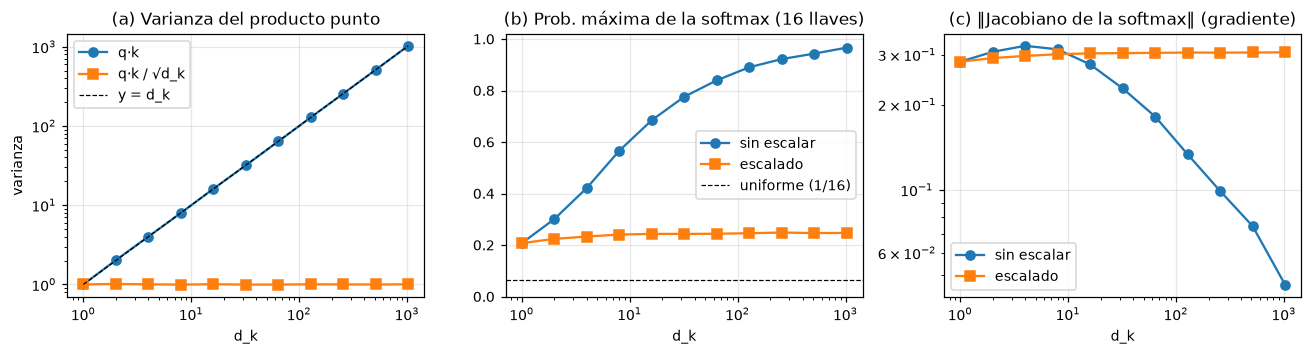

In [6]:
fig, ax = plt.subplots(1, 3, figsize=(12, 3.3))
ax[0].loglog(escala_df.d_k, escala_df.var_sin_escala, 'o-', label='q·k')
ax[0].loglog(escala_df.d_k, escala_df.var_con_escala, 's-', label='q·k / √d_k')
ax[0].loglog(escala_df.d_k, escala_df.d_k, 'k--', lw=0.8, label='y = d_k')
ax[0].set(title='(a) Varianza del producto punto', xlabel='d_k', ylabel='varianza'); ax[0].legend()
ax[1].semilogx(escala_df.d_k, escala_df.pmax_sin, 'o-', label='sin escalar')
ax[1].semilogx(escala_df.d_k, escala_df.pmax_con, 's-', label='escalado')
ax[1].axhline(1 / N_LLAVES, color='k', ls='--', lw=0.8, label='uniforme (1/16)')
ax[1].set(title='(b) Prob. máxima de la softmax (16 llaves)', xlabel='d_k', ylim=(0, 1.02)); ax[1].legend()
ax[2].loglog(escala_df.d_k, escala_df.normaJ_sin, 'o-', label='sin escalar')
ax[2].loglog(escala_df.d_k, escala_df.normaJ_con, 's-', label='escalado')
ax[2].set(title='(c) ‖Jacobiano de la softmax‖ (gradiente)', xlabel='d_k'); ax[2].legend()
fig.tight_layout(); guardar(fig, 'escalamiento.png'); plt.show()

La varianza de q·k sigue exactamente la recta y = d_k y al escalar se queda en 1. Sin escalar, con d_k = 64 la
softmax ya pone ~84 % de la masa en una sola llave (97 % con d_k = 1024) y la norma del Jacobiano cae de 0.30 a 0.18
(0.05 con d_k = 1024): los gradientes hacia Q y K se vuelven cada vez más pequeños. Con escalamiento ambas curvas quedan planas.

**Costo computacional.** Se mide el tiempo de la atención (batch 1, 8 cabezas, d_k = 64) para n de 128 a 8192 con la
implementación «ingenua» (materializa la matriz n × n) y con `F.scaled_dot_product_attention`, y la memoria de la
matriz de atención que hay que guardar (puntajes y probabilidades, float32).

In [7]:
def sincronizar():
    if DEV.type == 'cuda': torch.cuda.synchronize()
    elif DEV.type == 'mps': torch.mps.synchronize()

def cronometrar(fn, reps=10):
    fn(); sincronizar()                         # calentamiento
    t0 = time.perf_counter()
    for _ in range(reps): fn()
    sincronizar()
    return (time.perf_counter() - t0) / reps * 1000   # ms

H_B, D_B = 8, 64
filas = []
for n in [128, 256, 512, 1024, 2048, 4096, 8192]:
    q, k, v = (torch.randn(1, H_B, n, D_B, device=DEV) for _ in range(3))
    with torch.no_grad():
        t_ing = cronometrar(lambda: atencion(q, k, v)[0])
        t_sdpa = cronometrar(lambda: F.scaled_dot_product_attention(q, k, v))
    mem_matriz = 2 * H_B * n * n * 4 / 2**20          # puntajes + probabilidades (MB)
    mem_qkv = 3 * H_B * n * D_B * 4 / 2**20           # Q, K, V (MB), crecen linealmente
    filas.append({'n': n, 'ms_ingenua': t_ing, 'ms_sdpa': t_sdpa, 'MB_matriz_nxn': mem_matriz, 'MB_QKV': mem_qkv})
    del q, k, v
costo_df = pd.DataFrame(filas)
# Pendiente log-log entre n=2048 y n=8192 (≈ 2 si el costo es cuadrático).
sub = costo_df[costo_df.n >= 2048]
for col in ('ms_ingenua', 'ms_sdpa'):
    print(f'pendiente log-log de {col}: {np.polyfit(np.log(sub.n), np.log(sub[col]), 1)[0]:.2f}')
costo_df.to_csv(os.path.join(REPORTS, 'costo.csv'), index=False)
costo_df

pendiente log-log de ms_ingenua: 2.11
pendiente log-log de ms_sdpa: 2.00


,n,ms_ingenua,ms_sdpa,MB_matriz_nxn,MB_QKV
0,128,0.1825,0.1030,1.0,0.75
1,256,0.3676,0.2240,4.0,1.50
2,512,1.0054,0.3665,16.0,3.00
3,1024,1.1299,0.5501,64.0,6.00
4,2048,4.0774,2.0690,256.0,12.00
5,4096,16.7474,8.2779,1024.0,24.00
6,8192,76.4772,33.2154,4096.0,48.00


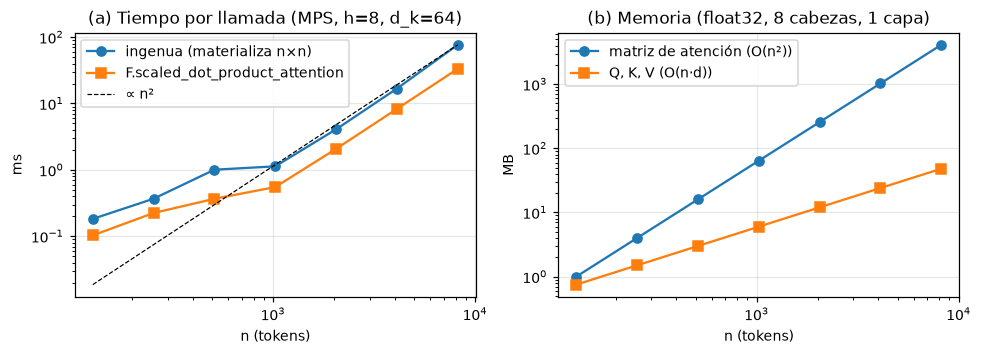

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(9, 3.3))
ax[0].loglog(costo_df.n, costo_df.ms_ingenua, 'o-', label='ingenua (materializa n×n)')
ax[0].loglog(costo_df.n, costo_df.ms_sdpa, 's-', label='F.scaled_dot_product_attention')
ref = costo_df.ms_ingenua.iloc[-1] * (costo_df.n / costo_df.n.iloc[-1]) ** 2
ax[0].loglog(costo_df.n, ref, 'k--', lw=0.8, label='∝ n²')
ax[0].set(title=f'(a) Tiempo por llamada ({DEV.type.upper()}, h=8, d_k=64)', xlabel='n (tokens)', ylabel='ms'); ax[0].legend()
ax[1].loglog(costo_df.n, costo_df.MB_matriz_nxn, 'o-', label='matriz de atención (O(n²))')
ax[1].loglog(costo_df.n, costo_df.MB_QKV, 's-', label='Q, K, V (O(n·d))')
ax[1].set(title='(b) Memoria (float32, 8 cabezas, 1 capa)', xlabel='n (tokens)', ylabel='MB'); ax[1].legend()
fig.tight_layout(); guardar(fig, 'costo.png'); plt.show()

Entre n = 2048 y 8192 el tiempo crece con pendiente log-log ≈ 2.1 (ingenua) y ≈ 2.0 (`F.sdpa`): duplicar la
longitud cuadruplica el costo (n = 8192 tarda ~75 ms frente a ~4 ms con n = 2048). Para n pequeño domina el costo
fijo de lanzar los kernels y la curva es más plana. El kernel fusionado es ~2× más rápido pero sigue siendo
cuadrático: optimiza el acceso a memoria, no la cantidad de operaciones. En memoria, la matriz de atención de **una
sola capa** con 8 cabezas ya ocupa 4 GB con n = 8192 (frente a 48 MB de Q, K y V); por eso materializarla es lo
primero que limita la longitud de contexto y es lo que evita FlashAttention.

### 5.4 Visualización de atención en modelos preentrenados (BERT y GPT-2)

Se cargan `bert-base-uncased` (encoder bidireccional, 12 capas × 12 cabezas) y `gpt2` (decoder causal, 12 × 12) con
`output_attentions=True` y `attn_implementation="eager"` (sección 1). `atenciones(...)` devuelve un tensor
(capas, cabezas, n, n) y los tokens.

In [9]:
tok_bert = AutoTokenizer.from_pretrained("bert-base-uncased")
bert = AutoModel.from_pretrained("bert-base-uncased", output_attentions=True, attn_implementation="eager").eval()
tok_gpt2 = AutoTokenizer.from_pretrained("gpt2")
gpt2 = AutoModel.from_pretrained("gpt2", output_attentions=True, attn_implementation="eager").eval()

@torch.no_grad()
def atenciones(modelo, tok, texto):
    """Devuelve (A, tokens) con A de forma (capas, cabezas, n, n) para una sola oración (sin padding)."""
    enc = tok(texto, return_tensors='pt')
    out = modelo(**enc)
    A = torch.stack(out.attentions)[:, 0]                       # tupla de 12 × (1, h, n, n) -> (12, h, n, n)
    toks = [t.replace('Ġ', '') for t in tok.convert_ids_to_tokens(enc.input_ids[0])]
    return A, toks

A_b, t_b = atenciones(bert, tok_bert, "The quick brown fox jumps over the lazy dog, and the dog sleeps.")
print('BERT  ->', len(bert.encoder.layer), 'capas; attentions[0]:', tuple(A_b[0].shape), '|', t_b)
A_g, t_g = atenciones(gpt2, tok_gpt2, "The quick brown fox jumps over the lazy dog, and the dog sleeps.")
print('GPT-2 ->', len(gpt2.h), 'capas; attentions[0]:', tuple(A_g[0].shape), '|', t_g)

BERT  -> 12 capas; attentions[0]: (12, 17, 17) | ['[CLS]', 'the', 'quick', 'brown', 'fox', 'jumps', 'over', 'the', 'lazy', 'dog', ',', 'and', 'the', 'dog', 'sleeps', '.', '[SEP]']


GPT-2 -> 12 capas; attentions[0]: (12, 15, 15) | ['The', 'quick', 'brown', 'fox', 'jumps', 'over', 'the', 'lazy', 'dog', ',', 'and', 'the', 'dog', 'sleeps', '.']


#### Patrones por cabeza

Para no elegir cabezas «a ojo», se mide en las 144 cabezas qué fracción promedio de la atención de cada token va a:
el token **anterior**, el **siguiente**, **sí mismo**, **[CLS]**, **[SEP]**, la **puntuación** y **otra aparición de
la misma palabra** («the», «dog»). Luego se grafica la cabeza más representativa de cada patrón (en capas distintas).

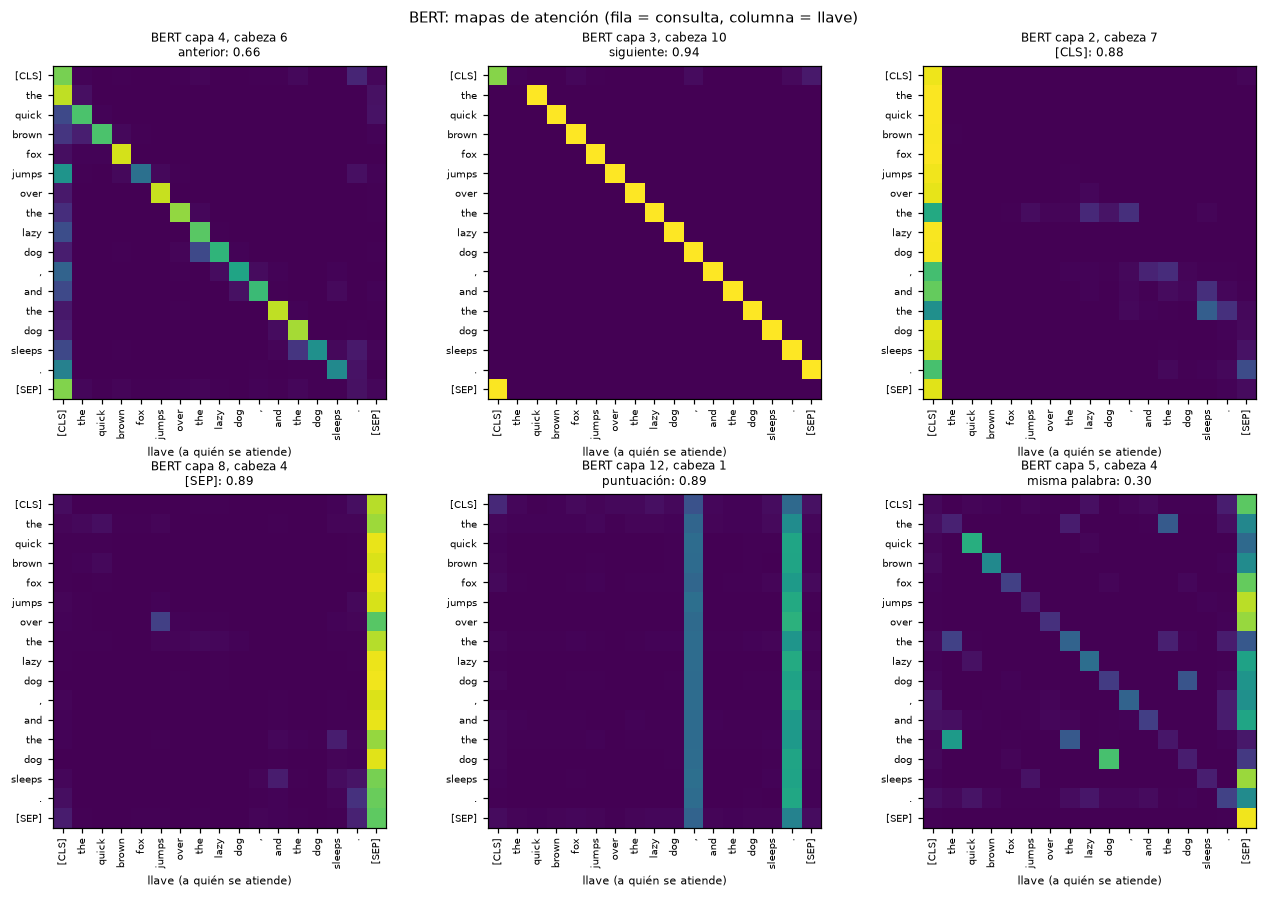

,patrón,capa,cabeza,atención media,promedio en las 144 cabezas
0,anterior,4,6,0.6630,0.0696
1,siguiente,3,10,0.9378,0.0935
2,[CLS],2,7,0.8817,0.1165
3,[SEP],8,4,0.8926,0.3076
4,puntuación,12,1,0.8946,0.1702
5,misma palabra,5,4,0.3044,0.0440


In [10]:
PUNT = set(',.;:!?')

def patrones(A, toks, especiales=True):
    """Fracción media de atención (sobre las filas que aplican) a cada patrón, por capa y cabeza."""
    L, H, n, _ = A.shape
    i = torch.arange(n)
    res = {}
    res['anterior'] = A[:, :, i[2:], i[2:] - 1].mean(-1)           # desde i=2 para no confundir con [CLS]/primer token
    res['siguiente'] = A[:, :, i[:-1], i[:-1] + 1].mean(-1)
    res['sí mismo'] = A[:, :, i, i].mean(-1)
    p = [j for j, t in enumerate(toks) if t in PUNT]
    res['puntuación'] = A[:, :, :, p].sum(-1).mean(-1)
    # misma palabra: filas de palabras repetidas -> otras posiciones con el mismo token
    # (en GPT-2 solo b < a: una palabra únicamente puede ver apariciones anteriores)
    pares = [(a, b) for a in range(n) for b in range(n) if (b < a if not especiales else a != b)
             and toks[a] == toks[b] and toks[a] not in PUNT
             and toks[a] not in ('[CLS]', '[SEP]')]
    res['misma palabra'] = torch.stack([A[:, :, a, b] for a, b in pares], -1).mean(-1)
    if especiales:
        res['[CLS]'] = A[:, :, :, 0].mean(-1)
        res['[SEP]'] = A[:, :, :, -1].mean(-1)
    else:
        res['primer token'] = A[:, :, 1:, 0].mean(-1)
    return res

def mejores_cabezas(res, orden):
    """Para cada patrón, la cabeza con mayor puntaje en una capa aún no usada."""
    usadas, sel = set(), []
    for pat in orden:
        M = res[pat].clone()
        for l in usadas: M[l] = -1
        l, h = divmod(int(M.argmax()), M.shape[1])
        usadas.add(l); sel.append((pat, l, h, M[l, h].item()))
    return sel

def mapa(ax, A2, toks, titulo, causal=False):
    ax.imshow(A2, cmap='viridis', vmin=0, vmax=1)
    ax.set_xticks(range(len(toks))); ax.set_xticklabels(toks, rotation=90, fontsize=6.5)
    ax.set_yticks(range(len(toks))); ax.set_yticklabels(toks, fontsize=6.5)
    ax.set_title(titulo, fontsize=8); ax.grid(False)
    ax.set_xlabel('llave (a quién se atiende)', fontsize=7)

pat_b = patrones(A_b, t_b)
sel_b = mejores_cabezas(pat_b, ['anterior', 'siguiente', '[CLS]', '[SEP]', 'puntuación', 'misma palabra'])
fig, axs = plt.subplots(2, 3, figsize=(12, 8.2))
for ax, (pat, l, h, v) in zip(axs.flat, sel_b):
    mapa(ax, A_b[l, h], t_b, f'BERT capa {l+1}, cabeza {h+1}\n{pat}: {v:.2f}')
fig.suptitle('BERT: mapas de atención (fila = consulta, columna = llave)', fontsize=10)
fig.tight_layout(); guardar(fig, 'bert_cabezas.png'); plt.show()

pd.DataFrame([{'patrón': p, 'capa': l + 1, 'cabeza': h + 1, 'atención media': v,
               'promedio en las 144 cabezas': pat_b[p].mean().item()} for p, l, h, v in sel_b])

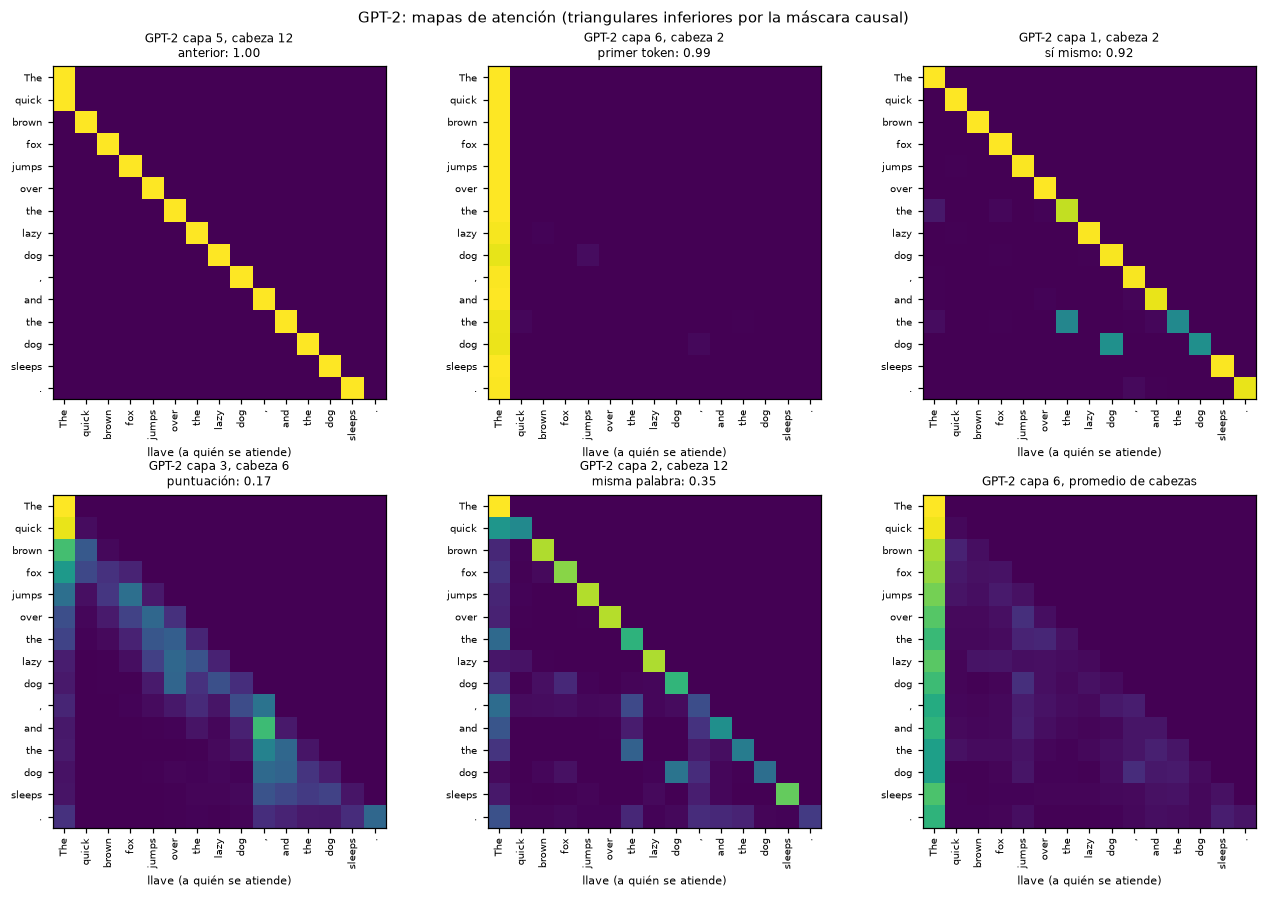

,patrón,capa,cabeza,atención media,promedio en las 144 cabezas
0,anterior,5,12,0.9999,0.1016
1,primer token,6,2,0.9913,0.6015
2,sí mismo,1,2,0.9178,0.1554
3,puntuación,3,6,0.1717,0.0368
4,misma palabra,2,12,0.3486,0.0356


In [11]:
pat_g = patrones(A_g, t_g, especiales=False)
sel_g = mejores_cabezas(pat_g, ['anterior', 'primer token', 'sí mismo', 'puntuación', 'misma palabra', 'siguiente'])
sel_g = [s for s in sel_g if s[0] != 'siguiente'][:5]          # en GPT-2 «siguiente» es imposible (causal)
fig, axs = plt.subplots(2, 3, figsize=(12, 8.2))
for ax, (pat, l, h, v) in zip(axs.flat, sel_g):
    mapa(ax, A_g[l, h], t_g, f'GPT-2 capa {l+1}, cabeza {h+1}\n{pat}: {v:.2f}')
# Último panel: promedio de todas las cabezas de la capa 6 para ver el patrón general.
mapa(axs.flat[-1], A_g[5].mean(0), t_g, 'GPT-2 capa 6, promedio de cabezas')
fig.suptitle('GPT-2: mapas de atención (triangulares inferiores por la máscara causal)', fontsize=10)
fig.tight_layout(); guardar(fig, 'gpt2_cabezas.png'); plt.show()

pd.DataFrame([{'patrón': p, 'capa': l + 1, 'cabeza': h + 1, 'atención media': v,
               'promedio en las 144 cabezas': pat_g[p].mean().item()} for p, l, h, v in sel_g])

In [12]:
# Figura compacta para el informe: 4 cabezas de BERT y 4 de GPT-2 (capas distintas).
d_b = {p: (l, h, v) for p, l, h, v in sel_b}; d_g = {p: (l, h, v) for p, l, h, v in sel_g}
paneles = [('BERT', A_b, t_b, d_b[p], p) for p in ('siguiente', 'anterior', '[SEP]', 'puntuación')] + \
          [('GPT-2', A_g, t_g, d_g[p], p) for p in ('anterior', 'primer token', 'sí mismo')]
fig, axs = plt.subplots(2, 4, figsize=(13, 7))
for ax, (mod, A_, tk, (l, h, v), p) in zip(axs.flat, paneles):
    mapa(ax, A_[l, h], tk, f'{mod} capa {l+1}, cabeza {h+1} ({p}: {v:.2f})'); ax.set_xlabel('')
mapa(axs.flat[-1], A_g[5].mean(0), t_g, 'GPT-2 capa 6, promedio de las 12 cabezas'); axs.flat[-1].set_xlabel('')
fig.tight_layout(); guardar(fig, 'mapas_informe.png'); plt.close(fig)

#### Correferencia de «it»: *tired* vs. *wide*

En «The animal didn't cross the street because it was too **tired**.» «it» se refiere al animal; con «too
**wide**» se refiere a la calle. Para cada una de las 144 cabezas de BERT se toma la fila de «it» y se calcula
Δ_tired = a(it→animal) − a(it→street) en la primera oración y Δ_wide = a(it→street) − a(it→animal) en la segunda.
Una cabeza «resuelve» la correferencia si **ambas** son positivas; se ordena por min(Δ_tired, Δ_wide).

In [13]:
o_tired = "The animal didn't cross the street because it was too tired."
o_wide = "The animal didn't cross the street because it was too wide."
A_t, tt = atenciones(bert, tok_bert, o_tired)
A_w, tw = atenciones(bert, tok_bert, o_wide)
i_it, i_an, i_st = tt.index('it'), tt.index('animal'), tt.index('street')
d_tired = A_t[:, :, i_it, i_an] - A_t[:, :, i_it, i_st]
d_wide = A_w[:, :, i_it, i_st] - A_w[:, :, i_it, i_an]
puntaje = torch.minimum(d_tired, d_wide)
filas = []
for idx in puntaje.flatten().argsort(descending=True)[:8].tolist():
    l, h = divmod(idx, 12)
    filas.append({'capa': l + 1, 'cabeza': h + 1,
                  'tired: it→animal': A_t[l, h, i_it, i_an].item(), 'tired: it→street': A_t[l, h, i_it, i_st].item(),
                  'wide: it→animal': A_w[l, h, i_it, i_an].item(), 'wide: it→street': A_w[l, h, i_it, i_st].item(),
                  'min(Δ)': puntaje[l, h].item()})
it_df = pd.DataFrame(filas)
it_df.to_csv(os.path.join(REPORTS, 'correferencia_it.csv'), index=False)
n_ok = int((puntaje > 0).sum()); n_inv = int(((-d_tired > 0) & (-d_wide > 0)).sum())
print(f'Cabezas con el cambio esperado (ambas Δ > 0): {n_ok} de 144')
print(f'Cabezas con el cambio contrario (animal con wide y street con tired): {n_inv} de 144')
print(f'Cabezas con min(Δ) > 0.05: {int((puntaje > 0.05).sum())}')
it_df

Cabezas con el cambio esperado (ambas Δ > 0): 22 de 144
Cabezas con el cambio contrario (animal con wide y street con tired): 3 de 144
Cabezas con min(Δ) > 0.05: 6


,capa,cabeza,tired: it→animal,tired: it→street,wide: it→animal,wide: it→street,min(Δ)
0,7,11,0.2843,0.0671,0.0119,0.5902,0.2172
1,9,5,0.2417,0.0145,0.0462,0.2091,0.1629
2,9,8,0.2052,0.0503,0.0611,0.1944,0.1333
3,5,11,0.3330,0.0952,0.1674,0.2883,0.1208
4,7,5,0.2386,0.1339,0.0815,0.2510,0.1047
5,9,4,0.0822,0.0256,0.0130,0.1594,0.0566
6,9,2,0.1150,0.0043,0.0154,0.0564,0.0409
7,12,9,0.0449,0.0074,0.0174,0.0760,0.0374


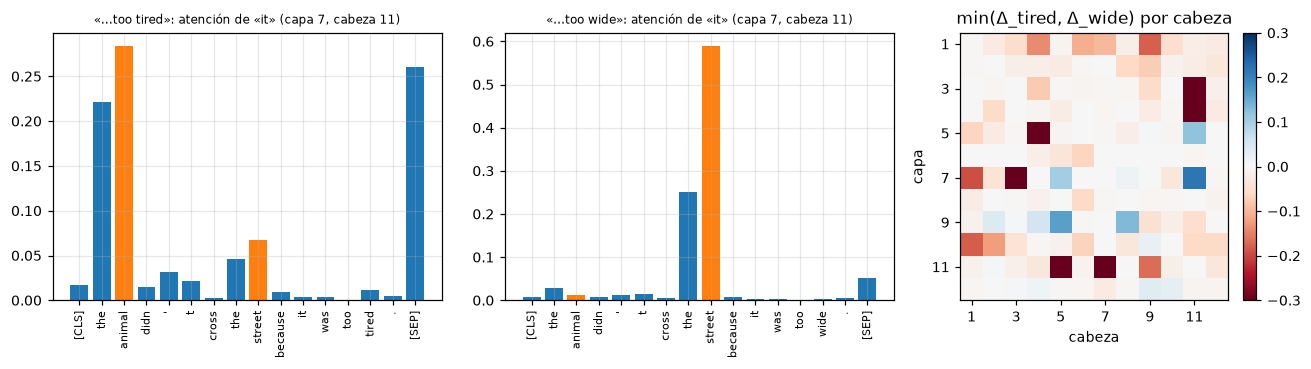

In [14]:
lb, hb = it_df.capa[0] - 1, it_df.cabeza[0] - 1
fig, axs = plt.subplots(1, 3, figsize=(12, 3.4), gridspec_kw={'width_ratios': [1.3, 1.3, 1]})
for ax, A_, tk, nombre in ((axs[0], A_t, tt, 'tired'), (axs[1], A_w, tw, 'wide')):
    col = ['tab:orange' if j in (i_an, i_st) else 'tab:blue' for j in range(len(tk))]
    ax.bar(range(len(tk)), A_[lb, hb, i_it].numpy(), color=col)
    ax.set_xticks(range(len(tk))); ax.set_xticklabels(tk, rotation=90, fontsize=7)
    ax.set_title(f'«…too {nombre}»: atención de «it» (capa {lb+1}, cabeza {hb+1})', fontsize=8)
im = axs[2].imshow(puntaje.numpy(), cmap='RdBu', vmin=-0.3, vmax=0.3)
axs[2].set(title='min(Δ_tired, Δ_wide) por cabeza', xlabel='cabeza', ylabel='capa',
           xticks=range(0, 12, 2), xticklabels=range(1, 13, 2), yticks=range(0, 12, 2), yticklabels=range(1, 13, 2))
axs[2].grid(False); fig.colorbar(im, ax=axs[2], fraction=0.046)
fig.tight_layout(); guardar(fig, 'correferencia_it.png'); plt.show()

**Nota sobre GPT-2.** En un modelo causal la fila de «it» **no puede ver** «tired» ni «wide» (vienen después), así
que la atención de «it» es idéntica en ambas oraciones; la diferencia solo puede aparecer en tokens posteriores
(p. ej. desde el «.» final). Se comprueba:

In [15]:
G_t, gt = atenciones(gpt2, tok_gpt2, o_tired)
G_w, gw = atenciones(gpt2, tok_gpt2, o_wide)
j_it, j_an, j_st = gt.index('it'), gt.index('animal'), gt.index('street')
print('máx |Δ| en la fila de «it» entre tired y wide:', (G_t[:, :, j_it] - G_w[:, :, j_it]).abs().max().item())
dd = (G_t[:, :, -1, j_an] - G_t[:, :, -1, j_st]) - (G_w[:, :, -1, j_an] - G_w[:, :, -1, j_st])
l, h = divmod(int(dd.argmax()), 12)
print(f'Desde el «.» final, la cabeza que más cambia es capa {l+1}, cabeza {h+1}: '
      f'tired animal/street = {G_t[l,h,-1,j_an]:.3f}/{G_t[l,h,-1,j_st]:.3f}, '
      f'wide animal/street = {G_w[l,h,-1,j_an]:.3f}/{G_w[l,h,-1,j_st]:.3f}')

máx |Δ| en la fila de «it» entre tired y wide: 0.0
Desde el «.» final, la cabeza que más cambia es capa 6, cabeza 11: tired animal/street = 0.087/0.072, wide animal/street = 0.065/0.161


#### GPT-2: matriz triangular inferior y *attention sinks*

Se verifica en las 144 cabezas que todo lo que está encima de la diagonal es exactamente 0 y que cada fila suma 1.
Luego, sobre un conjunto de 20 oraciones, se mide en cada capa la fracción de atención que recibe el **primer
token** (promedio sobre cabezas y sobre las consultas i ≥ 1, excluyendo la fila 0 que trivialmente vale 1) y se
compara con lo que recibiría si la atención fuera uniforme sobre los tokens visibles (1/(i+1)).

In [16]:
ORACIONES = [
    "The quick brown fox jumps over the lazy dog, and the dog sleeps.",
    "The animal didn't cross the street because it was too tired.",
    "The animal didn't cross the street because it was too wide.",
    "She opened the window because the room was too hot.",
    "Researchers at the university published a new study on climate change last week.",
    "My brother bought a red car, but he rarely drives it to work.",
    "The trophy didn't fit in the suitcase because it was too big.",
    "After the rain stopped, the children ran outside to play in the park.",
    "Transformers process all the tokens of a sentence in parallel.",
    "I think that the movie we watched yesterday was better than the book.",
    "The president of the company announced that profits had doubled.",
    "Water boils at one hundred degrees Celsius at sea level.",
    "If you heat the metal, it expands and becomes softer.",
    "The cat sat on the mat while the dog barked at the mailman.",
    "Guatemala City is the capital and largest city of Guatemala.",
    "He forgot his keys at home, so he had to call a locksmith.",
    "The students who studied hard passed the difficult exam easily.",
    "Deep learning models need large amounts of data and computation.",
    "The old man the boats while the young sleep on the shore.",
    "Although it was late, the restaurant was still full of people.",
]

# 1) Triangularidad en todas las cabezas y oraciones.
max_sup, max_fila = 0.0, 0.0
for o in ORACIONES:
    G, _ = atenciones(gpt2, tok_gpt2, o)
    n = G.shape[-1]
    sup = torch.triu(torch.ones(n, n, dtype=torch.bool), 1)
    max_sup = max(max_sup, G[..., sup].abs().max().item())
    max_fila = max(max_fila, (G.sum(-1) - 1).abs().max().item())
print(f'máx. peso por encima de la diagonal (20 oraciones × 144 cabezas): {max_sup:.2e}')
print(f'máx. |suma de fila − 1|: {max_fila:.2e}')

# 2) Fracción de atención al primer token por capa.
def frac_primer_token(modelo, tok, oraciones, prefijo=''):
    acc, unif = np.zeros(12), []
    for o in oraciones:
        G, _ = atenciones(modelo, tok, prefijo + o)
        n = G.shape[-1]
        acc += G[:, :, 1:, 0].mean((1, 2)).numpy()                      # capas
        unif.append(np.mean(1 / (np.arange(1, n) + 1)))
    return acc / len(oraciones), float(np.mean(unif))

sink, unif = frac_primer_token(gpt2, tok_gpt2, ORACIONES)
sink_bos, _ = frac_primer_token(gpt2, tok_gpt2, ORACIONES, prefijo=tok_gpt2.bos_token)   # <|endoftext|> al inicio
# Control: cambiar la primera palabra por otra arbitraria no cambia el fenómeno (depende de la posición).
otras = ['Yesterday ' + o[0].lower() + o[1:] for o in ORACIONES]
sink_otro, _ = frac_primer_token(gpt2, tok_gpt2, otras)
sink_df = pd.DataFrame({'capa': range(1, 13), 'primer token (oración)': sink,
                        'primer token = "Yesterday"': sink_otro, 'primer token = <|endoftext|>': sink_bos})
sink_df.to_csv(os.path.join(REPORTS, 'attention_sinks.csv'), index=False)
print(f'Referencia uniforme (promedio de 1/(i+1)): {unif:.3f}')
sink_df

máx. peso por encima de la diagonal (20 oraciones × 144 cabezas): 0.00e+00
máx. |suma de fila − 1|: 2.38e-07


Referencia uniforme (promedio de 1/(i+1)): 0.182


,capa,primer token (oración),"primer token = ""Yesterday""",primer token = <|endoftext|>
0,1,0.2444,0.2343,0.2870
1,2,0.4138,0.3955,0.4128
2,3,0.4125,0.4025,0.3467
3,4,0.5506,0.5392,0.5358
4,5,0.5761,0.5661,0.5615
5,6,0.7527,0.7345,0.7467
6,7,0.7248,0.7116,0.7183
7,8,0.8081,0.7970,0.8152
8,9,0.7422,0.7235,0.7396
9,10,0.8226,0.8106,0.8225


In [17]:
# Sink por cabeza en la oración del ejemplo: ¿cuántas cabezas ponen > 50 % en el primer token?
G, _ = atenciones(gpt2, tok_gpt2, ORACIONES[0])
por_cabeza = G[:, :, 1:, 0].mean(-1)
print(f'Cabezas con > 50 % de atención al primer token: {(por_cabeza > 0.5).sum().item()} de 144; '
      f'> 80 %: {(por_cabeza > 0.8).sum().item()}')
print('Por capa (cabezas > 50 %):', (por_cabeza > 0.5).sum(1).tolist())

Cabezas con > 50 % de atención al primer token: 103 de 144; > 80 %: 34
Por capa (cabezas > 50 %): [0, 5, 3, 7, 9, 10, 11, 12, 12, 12, 12, 10]


#### Entropía de la atención por capa: BERT vs. GPT-2

Para cada fila (consulta) se calcula H = −Σ_j a_j log a_j (en nats). Como el número de llaves visibles cambia (en
GPT-2 la fila i solo ve i + 1 tokens), también se reporta la **entropía normalizada** H / log(#llaves) ∈ [0, 1]
(1 = atención uniforme, 0 = toda en un token). En GPT-2 se excluye la fila 0 (una sola llave). Promedio sobre
cabezas, filas y las 20 oraciones.

In [18]:
def entropia_por_capa(modelo, tok, oraciones, causal):
    H, Hn = np.zeros(12), np.zeros(12)
    for o in oraciones:
        A, _ = atenciones(modelo, tok, o)
        n = A.shape[-1]
        h = -(A * torch.log(A.clamp_min(1e-12))).sum(-1)                     # (capas, cabezas, n)
        nllaves = torch.arange(1, n + 1).float() if causal else torch.full((n,), float(n))
        filas = slice(1, None) if causal else slice(None)
        H += h[..., filas].mean((1, 2)).numpy()
        Hn += (h / torch.log(nllaves))[..., filas].mean((1, 2)).numpy()
    return H / len(oraciones), Hn / len(oraciones)

H_b, Hn_b = entropia_por_capa(bert, tok_bert, ORACIONES, causal=False)
H_g, Hn_g = entropia_por_capa(gpt2, tok_gpt2, ORACIONES, causal=True)
ent_df = pd.DataFrame({'capa': range(1, 13), 'BERT H': H_b, 'BERT H norm.': Hn_b, 'GPT-2 H': H_g, 'GPT-2 H norm.': Hn_g})
ent_df.to_csv(os.path.join(REPORTS, 'entropia.csv'), index=False)
ent_df

,capa,BERT H,BERT H norm.,GPT-2 H,GPT-2 H norm.
0,1,2.0584,0.7560,1.2969,0.6773
1,2,1.6490,0.6054,1.4196,0.7179
2,3,1.4328,0.5263,1.2982,0.6650
3,4,1.6269,0.5977,1.0327,0.5313
4,5,1.4153,0.5199,0.8986,0.4561
5,6,1.1697,0.4293,0.7505,0.3841
6,7,1.2082,0.4435,0.8623,0.4385
7,8,1.1669,0.4288,0.6366,0.3225
8,9,1.3679,0.5022,0.8293,0.4227
9,10,1.4976,0.5505,0.5929,0.3035


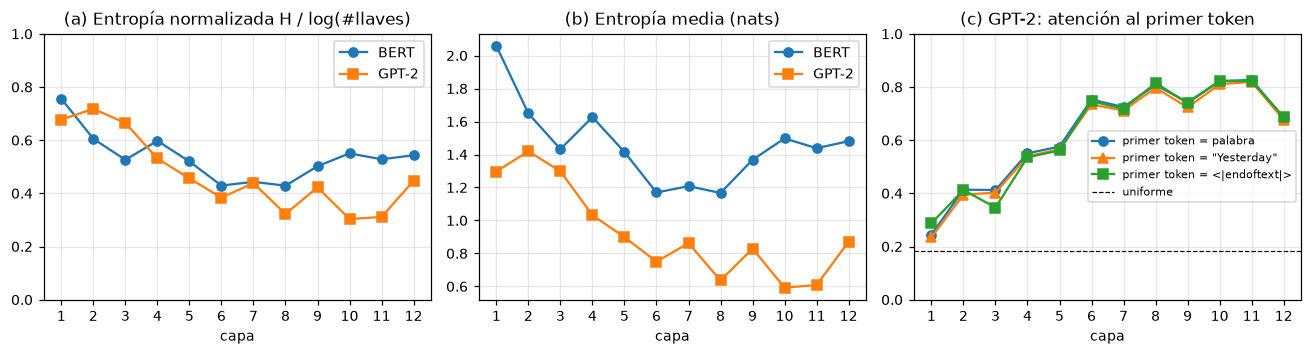

In [19]:
fig, ax = plt.subplots(1, 3, figsize=(12, 3.3))
ax[0].plot(ent_df.capa, ent_df['BERT H norm.'], 'o-', label='BERT')
ax[0].plot(ent_df.capa, ent_df['GPT-2 H norm.'], 's-', label='GPT-2')
ax[0].set(title='(a) Entropía normalizada H / log(#llaves)', xlabel='capa', ylim=(0, 1), xticks=range(1, 13)); ax[0].legend()
ax[1].plot(ent_df.capa, ent_df['BERT H'], 'o-', label='BERT')
ax[1].plot(ent_df.capa, ent_df['GPT-2 H'], 's-', label='GPT-2')
ax[1].set(title='(b) Entropía media (nats)', xlabel='capa', xticks=range(1, 13)); ax[1].legend()
ax[2].plot(sink_df.capa, sink_df['primer token (oración)'], 'o-', label='primer token = palabra')
ax[2].plot(sink_df.capa, sink_df['primer token = "Yesterday"'], '^-', label='primer token = "Yesterday"')
ax[2].plot(sink_df.capa, sink_df['primer token = <|endoftext|>'], 's-', label='primer token = <|endoftext|>')
ax[2].axhline(unif, color='k', ls='--', lw=0.8, label='uniforme')
ax[2].set(title='(c) GPT-2: atención al primer token', xlabel='capa', ylim=(0, 1), xticks=range(1, 13)); ax[2].legend(fontsize=7)
fig.tight_layout(); guardar(fig, 'entropia_sinks.png'); plt.show()

#### ¿Todas las cabezas son útiles? Ablación de cabezas en BERT

Siguiendo a Michel et al. [17], se «apaga» una cabeza a la vez (se ponen en cero sus 64 dimensiones de salida antes
de la proyección W_O, con un *hook*, porque `head_mask` ya no existe en transformers 5) y se mide cuánto sube la
pérdida de *masked language modeling* (15 % de tokens enmascarados, 3 máscaras distintas) sobre las 20 oraciones.
Después se apagan cabezas acumulativamente, de la menos a la más importante, y la curva se evalúa en **otras 20
oraciones** (para no medir la poda sobre los mismos datos con que se ordenaron las cabezas).

In [20]:
ORACIONES_EVAL = [
    "The weather was so cold that the lake froze overnight.",
    "She plays the violin in the city orchestra every weekend.",
    "Most birds build their nests in the spring.",
    "The engineer fixed the bridge before the storm arrived.",
    "Coffee is one of the most traded goods in the world.",
    "The teacher asked the students to read the first chapter.",
    "Our team lost the final match by a single goal.",
    "The museum displays paintings from the sixteenth century.",
    "He woke up early because he had a flight to catch.",
    "Volcanoes form where tectonic plates meet or separate.",
    "The library will be closed on Sunday for repairs.",
    "Doctors recommend drinking enough water during the day.",
    "The novel tells the story of a family during the war.",
    "A strong wind knocked down several trees in the park.",
    "The company plans to open three new stores next year.",
    "Children usually learn to walk before they learn to talk.",
    "The scientist measured the temperature of the solution.",
    "We watched the sunset from the top of the hill.",
    "The government announced new rules for public transport.",
    "My grandmother makes the best soup in the family.",
]

mlm = BertForMaskedLM.from_pretrained("bert-base-uncased", attn_implementation="eager").eval()
apagadas = set()                                   # {(capa, cabeza)}

def hook_capa(l):
    def pre(modulo, args):
        x = args[0]
        hs = [h for (ll, h) in apagadas if ll == l]
        if not hs: return None
        x = x.clone()
        for h in hs: x[..., h * 64:(h + 1) * 64] = 0
        return (x,)
    return pre
for l, capa in enumerate(mlm.bert.encoder.layer):
    capa.attention.output.dense.register_forward_pre_hook(hook_capa(l))

def lotes_mlm(oraciones, semillas=(0, 1, 2)):
    """Lotes fijos con 15 % de los tokens (no especiales) enmascarados, una máscara por semilla."""
    enc = tok_bert(oraciones, return_tensors='pt', padding=True)
    especial = torch.tensor([tok_bert.get_special_tokens_mask(f, already_has_special_tokens=True)
                             for f in enc.input_ids.tolist()]).bool()
    elegibles = (~especial) & enc.attention_mask.bool()
    lotes = []
    for s in semillas:
        g = torch.Generator().manual_seed(SEED + s)
        masc = (torch.rand(enc.input_ids.shape, generator=g) < 0.15) & elegibles
        etiquetas = torch.full_like(enc.input_ids, -100); etiquetas[masc] = enc.input_ids[masc]
        entrada = enc.input_ids.clone(); entrada[masc] = tok_bert.mask_token_id
        lotes.append((entrada, enc.attention_mask, etiquetas))
    return lotes

@torch.no_grad()
def perdida_mlm(lotes):
    return float(np.mean([mlm(input_ids=e, attention_mask=m, labels=y).loss.item() for e, m, y in lotes]))

lotes_imp, lotes_eval = lotes_mlm(ORACIONES), lotes_mlm(ORACIONES_EVAL)
print('tokens enmascarados (importancia / evaluación):',
      sum(int((y != -100).sum()) for *_, y in lotes_imp), '/', sum(int((y != -100).sum()) for *_, y in lotes_eval))

base = perdida_mlm(lotes_imp)
imp = np.zeros((12, 12))
for l in range(12):
    for h in range(12):
        apagadas.clear(); apagadas.add((l, h))
        imp[l, h] = perdida_mlm(lotes_imp) - base
apagadas.clear()
l_max, h_max = np.unravel_index(imp.argmax(), imp.shape)
print(f'pérdida base: {base:.3f}')
print(f'Δ pérdida al apagar una cabeza: mediana {np.median(imp):.4f}, máx {imp.max():.3f} (capa {l_max+1}, cabeza {h_max+1})')
print(f'Cabezas cuyo apagado cambia la pérdida < 1 %: {(np.abs(imp) < 0.01 * base).sum()} de 144; '
      f'que la BAJAN: {(imp < 0).sum()}')
print('Δ pérdida promedio por capa:', imp.mean(1).round(4).tolist())

# Poda acumulativa de la menos a la más importante, evaluada en las oraciones nuevas.
orden = np.dstack(np.unravel_index(np.argsort(imp, axis=None), imp.shape))[0]
base_eval = perdida_mlm(lotes_eval)
curva = [(0, base_eval)]
for k, (l, h) in enumerate(orden, 1):
    apagadas.add((int(l), int(h)))
    if k % 12 == 0: curva.append((k, perdida_mlm(lotes_eval)))
apagadas.clear()
poda_df = pd.DataFrame(curva, columns=['cabezas apagadas', 'pérdida MLM (eval)'])
poda_df['% cabezas'] = poda_df['cabezas apagadas'] / 144 * 100
poda_df.to_csv(os.path.join(REPORTS, 'poda_cabezas.csv'), index=False)
poda_df.T

tokens enmascarados (importancia / evaluación): 123 / 104


pérdida base: 2.239
Δ pérdida al apagar una cabeza: mediana 0.0031, máx 0.055 (capa 11, cabeza 6)
Cabezas cuyo apagado cambia la pérdida < 1 %: 124 de 144; que la BAJAN: 56
Δ pérdida promedio por capa: [-0.0021, -0.0002, 0.0015, 0.0037, 0.0072, 0.0046, 0.0074, 0.0068, 0.0069, 0.007, 0.0046, 0.0015]


,0,1,2,3,4,5,6,7,8,9,10,11,12
cabezas apagadas,0.0000,12.0000,24.0000,36.0000,48.0000,60.0000,72.000,84.0000,96.0000,108.0000,120.0000,132.0000,144.0000
pérdida MLM (eval),1.7774,1.7529,1.7819,1.8167,1.8800,1.8783,2.018,2.2880,2.5167,2.5885,3.4009,7.7307,7.9004
% cabezas,0.0000,8.3333,16.6667,25.0000,33.3333,41.6667,50.000,58.3333,66.6667,75.0000,83.3333,91.6667,100.0000


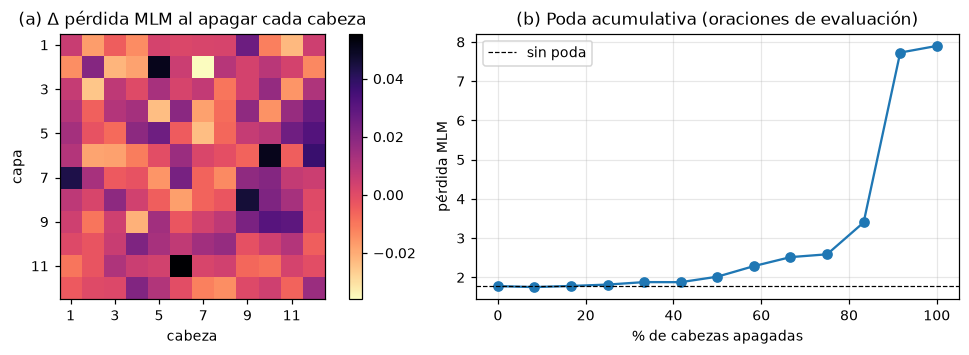

In [21]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3.3))
im = ax[0].imshow(imp, cmap='magma_r')
ax[0].set(title='(a) Δ pérdida MLM al apagar cada cabeza', xlabel='cabeza', ylabel='capa',
          xticks=range(0, 12, 2), xticklabels=range(1, 13, 2), yticks=range(0, 12, 2), yticklabels=range(1, 13, 2))
ax[0].grid(False); fig.colorbar(im, ax=ax[0], fraction=0.046)
ax[1].plot(poda_df['% cabezas'], poda_df['pérdida MLM (eval)'], 'o-')
ax[1].axhline(base_eval, color='k', ls='--', lw=0.8, label='sin poda')
ax[1].set(title='(b) Poda acumulativa (oraciones de evaluación)', xlabel='% de cabezas apagadas', ylabel='pérdida MLM')
ax[1].legend()
fig.tight_layout(); guardar(fig, 'ablacion_cabezas.png'); plt.show()

#### ¿La atención explica la predicción? Atención vs. gradiente × entrada en GPT-2

Se quita la última palabra de cada oración y GPT-2 predice la siguiente; para esa posición se compara la atención que recibe cada token previo
(promedio de cabezas de la última capa y de todas las capas) con una atribución basada en gradientes: la norma de
gradiente × embedding de entrada para el logit del token predicho. Si la atención «explicara» la predicción, ambos
rankings deberían coincidir (correlación de Spearman alta) [14][15].

In [22]:
lm = GPT2LMHeadModel.from_pretrained("gpt2", attn_implementation="eager").eval()

def spearman(a, b):
    ra, rb = pd.Series(a).rank().values, pd.Series(b).rank().values
    return float(np.corrcoef(ra, rb)[0, 1])

filas, ejemplo = [], None
prefijos = list(dict.fromkeys(o.rstrip('.').rsplit(' ', 1)[0] for o in ORACIONES))   # sin la última palabra (tired/wide quedan iguales)
for o in prefijos:
    ids = tok_gpt2(o, return_tensors='pt').input_ids
    emb = lm.transformer.wte(ids).detach().requires_grad_(True)
    out = lm(inputs_embeds=emb, output_attentions=True)
    pred = out.logits[0, -1].argmax()
    out.logits[0, -1, pred].backward()
    sal = (emb.grad[0] * emb[0]).norm(dim=-1).detach().numpy()          # gradiente × entrada por token
    att_ult = out.attentions[-1][0, :, -1].mean(0).detach().numpy()       # última capa, fila del último token
    att_tod = torch.stack(out.attentions)[:, 0, :, -1].mean((0, 1)).detach().numpy()
    filas.append({'oración': o[:45], 'predicción': tok_gpt2.decode(pred),
                  'ρ última capa': spearman(att_ult, sal), 'ρ todas las capas': spearman(att_tod, sal),
                  'ρ última capa (sin 1.er token)': spearman(att_ult[1:], sal[1:]),
                  'att. al 1.er token': att_ult[0], 'saliencia del 1.er token (%)': 100 * sal[0] / sal.sum()})
    if ejemplo is None and 'because it was too' in o:
        ejemplo = ([t.replace('Ġ', '') for t in tok_gpt2.convert_ids_to_tokens(ids[0])], att_ult, sal, tok_gpt2.decode(pred))
fiel_df = pd.DataFrame(filas)
fiel_df.to_csv(os.path.join(REPORTS, 'atencion_vs_gradiente.csv'), index=False)
print(fiel_df[['ρ última capa', 'ρ todas las capas', 'ρ última capa (sin 1.er token)', 'att. al 1.er token',
               'saliencia del 1.er token (%)']].mean().round(3))
fiel_df

ρ última capa                     0.174
ρ todas las capas                 0.061
ρ última capa (sin 1.er token)    0.207
att. al 1.er token                0.628
saliencia del 1.er token (%)      9.578
dtype: float64


,oración,predicción,ρ última capa,ρ todas las capas,ρ última capa (sin 1.er token),att. al 1.er token,saliencia del 1.er token (%)
0,"The quick brown fox jumps over the lazy dog,",is,-0.3736,-0.1758,-0.4895,0.6241,7.3310
1,The animal didn't cross the street because it,scared,-0.0636,0.0727,-0.2000,0.6057,9.6435
2,She opened the window because the room was to,small,-0.2333,-0.3833,0.0952,0.6266,5.4433
3,Researchers at the university published a new,week,0.1748,-0.1259,0.0273,0.7833,11.6615
4,"My brother bought a red car, but he rarely dr",work,0.5220,0.2582,0.6084,0.6808,5.3962
5,The trophy didn't fit in the suitcase because,big,0.0490,-0.0490,0.1000,0.6016,5.8000
6,"After the rain stopped, the children ran outs",rain,-0.0055,-0.0110,0.1049,0.6522,6.3404
7,Transformers process all the tokens of a sent,a,0.8303,0.1879,0.7667,0.4995,33.1166
8,I think that the movie we watched yesterday w,one,0.4406,0.1958,0.4545,0.4856,8.5568
9,The president of the company announced that p,been,-0.3333,-0.2333,-0.0476,0.6779,4.4120


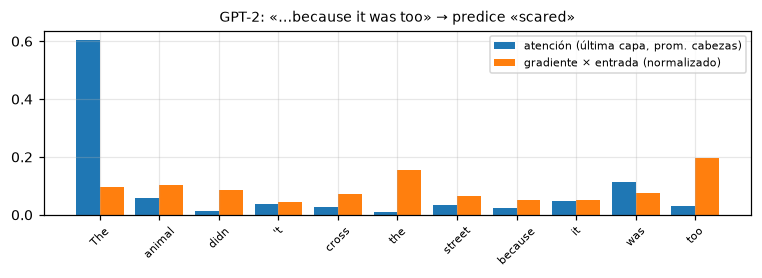

In [23]:
tk, att, sal, pred = ejemplo
fig, ax = plt.subplots(figsize=(7, 2.6))
x = np.arange(len(tk))
ax.bar(x - 0.2, att / att.sum(), 0.4, label='atención (última capa, prom. cabezas)')
ax.bar(x + 0.2, sal / sal.sum(), 0.4, label='gradiente × entrada (normalizado)')
ax.set_xticks(x); ax.set_xticklabels(tk, rotation=45, fontsize=7)
ax.set_title(f'GPT-2: «…because it was too» → predice «{pred.strip()}»', fontsize=9); ax.legend(fontsize=7)
fig.tight_layout(); guardar(fig, 'atencion_vs_gradiente.png'); plt.show()

#### Opcional: bertviz

`head_view` permite recorrer interactivamente todas las capas y cabezas (la vista se renderiza como HTML en Jupyter).

In [24]:
try:
    from bertviz import head_view
    enc_t = tok_bert(o_tired, return_tensors='pt')
    with torch.no_grad():
        att_t = bert(**enc_t).attentions
    head_view(att_t, tok_bert.convert_ids_to_tokens(enc_t.input_ids[0]))
except ImportError:
    print('bertviz no está instalado: pip install bertviz')

<IPython.core.display.Javascript object>

### Lectura de los resultados de 5.4

- **Patrones claros por cabeza.** En BERT hay cabezas casi «puras»: capa 3 cabeza 10 atiende al token **siguiente**
  (0.94 de su atención), capa 4 cabeza 6 al **anterior** (0.66), capa 2 cabeza 7 a **[CLS]** (0.88), capa 8
  cabeza 4 a **[SEP]** (0.89) y capa 12 cabeza 1 a la **puntuación** (0.89), frente a promedios de 0.07–0.17 en las
  144 cabezas. En GPT-2, capa 5 cabeza 12 atiende al **anterior** con 1.00 y capa 1 cabeza 2 a **sí misma** (y a
  la aparición previa de «the» y «dog»). La atención a [SEP] es masiva en las capas intermedias (promedio 0.31):
  Clark et al. [16] la interpretan como una operación «nula» cuando la cabeza no encuentra nada útil.
- **«it»:** 22 de 144 cabezas de BERT cambian en el sentido correcto (animal con *tired*, street con *wide*) y solo
  3 al revés; la más clara es capa 7 cabeza 11 (it→animal 0.28 vs 0.07 con *tired*; it→street 0.59 vs 0.01 con
  *wide*). Están en capas medias-altas (5, 7, 9): el adjetivo, que está **después** de «it», tiene que propagarse
  antes de que la cabeza pueda decidir. En GPT-2 la fila de «it» es **idéntica** en ambas oraciones (Δ = 0): un
  modelo causal no puede resolver esta correferencia en la posición de «it».
- **GPT-2 es triangular inferior** en las 20 oraciones × 144 cabezas (máximo encima de la diagonal = 0 exacto) y
  el **primer token** se lleva de 24 % (capa 1) a ~82 % (capas 10–11) de la atención, frente a 18 % si fuera
  uniforme; 103 de 144 cabezas le dan más de la mitad. Pasa igual si el primer token es otra palabra
  («Yesterday») o `<|endoftext|>`: depende de la **posición**, no del contenido. Es el *attention sink* de Xiao et
  al. [13]: como la softmax obliga a repartir una masa de 1, las cabezas que «no quieren» atender a nada la
  descargan en el primer token, que todas las posiciones ven. Por eso StreamingLLM conserva siempre esos primeros
  tokens en la caché al usar una ventana deslizante.
- **Entropía:** en ambos modelos las primeras capas son las más difusas (H normalizada 0.76 en BERT y ~0.7 en
  GPT-2). En **GPT-2** la atención se concentra con la profundidad (0.30–0.32 en las capas 10–11), pero en buena
  parte porque se concentra **en el sink**; en **BERT** baja hasta las capas 6–8 (0.43, dominadas por [SEP]) y
  vuelve a ser más difusa en las capas finales (0.50–0.55), consistente con Clark et al. [16].
- **Ablación:** apagar una sola cabeza cambia la pérdida de MLM en menos de 1 % en 124 de 144 casos (en 56 incluso
  la baja); al apagar acumulativamente el 42 % menos importante la pérdida en oraciones nuevas solo pasa de 1.78 a
  1.88, y se dispara a partir de ~75 %. Las capas 1–2 son las más prescindibles individualmente.
- **Atención vs. gradiente:** la correlación de Spearman entre la atención de la última capa y gradiente × entrada
  es baja (ρ ≈ 0.17 en promedio, negativa en varias oraciones); el primer token recibe ~63 % de la atención pero
  solo ~10 % de la atribución.

## 6. Verificaciones

### 6.1 La implementación propia contra PyTorch

Se comprueba numéricamente que lo implementado en 5.1–5.2 coincide con las funciones de la sección 4 y que las
máscaras se comportan como dice la documentación:

1. `atencion` vs. `F.scaled_dot_product_attention` (sin máscara, causal y con máscara booleana de padding).
2. `MultiHeadPropia` vs. `nn.MultiheadAttention` copiando los pesos (salida y pesos por cabeza / promediados),
   incluyendo `key_padding_mask` y la máscara causal con la **convención invertida** (True = prohibido).
3. `generate_square_subsequent_mask`: forma y valores, y que un `TransformerEncoder` con esa máscara es causal
   (cambiar un token futuro no altera las salidas anteriores).
4. Propiedades: filas de la softmax suman 1, la self-attention sin posiciones es equivariante a permutaciones, y
   Post-LN / Pre-LN tienen los mismos parámetros.

In [25]:
fijar_semilla()
verif = []
def registrar(nombre, a, b, tol=1e-5):
    err = (a - b).abs().max().item()
    verif.append({'verificación': nombre, 'error máx.': err, 'ok': err < tol})

# 1. atencion propia vs F.scaled_dot_product_attention
q, k, v = (torch.randn(2, 4, 7, 16) for _ in range(3))
registrar('atención vs F.sdpa (sin máscara)', atencion(q, k, v)[0], F.scaled_dot_product_attention(q, k, v))
registrar('atención vs F.sdpa (is_causal=True)', atencion(q, k, v, causal=True)[0],
          F.scaled_dot_product_attention(q, k, v, is_causal=True))
pad = torch.ones(2, 1, 1, 7, dtype=torch.bool); pad[1, ..., 5:] = False      # True = puede atender
registrar('atención vs F.sdpa (attn_mask booleana)', atencion(q, k, v, mascara=pad)[0],
          F.scaled_dot_product_attention(q, k, v, attn_mask=pad))
registrar('atención vs F.sdpa (scale=0.5)', atencion(q, k, v, escala=0.5)[0],
          F.scaled_dot_product_attention(q, k, v, scale=0.5))
registrar('ejercicio a mano vs F.sdpa', salida, F.scaled_dot_product_attention(Q, K, V))

# 2. MultiHeadPropia vs nn.MultiheadAttention con los mismos pesos
d_model, h = 32, 4
ref = nn.MultiheadAttention(d_model, h, batch_first=True).eval()
mia = MultiHeadPropia(d_model, h).eval()
with torch.no_grad():
    Wq, Wk, Wv = ref.in_proj_weight.chunk(3); bq, bk, bv = ref.in_proj_bias.chunk(3)
    for lin, W, b in ((mia.W_q, Wq, bq), (mia.W_k, Wk, bk), (mia.W_v, Wv, bv)):
        lin.weight.copy_(W); lin.bias.copy_(b)
    mia.W_o.weight.copy_(ref.out_proj.weight); mia.W_o.bias.copy_(ref.out_proj.bias)
x = torch.randn(2, 6, d_model)
with torch.no_grad():
    y_ref, p_ref = ref(x, x, x, need_weights=True, average_attn_weights=False)
    y_mia, p_mia = mia(x)
    registrar('MHA propia vs nn.MultiheadAttention (salida)', y_mia, y_ref)
    registrar('MHA propia vs nn.MHA (pesos por cabeza)', p_mia, p_ref)
    _, p_prom = ref(x, x, x, average_attn_weights=True)
    registrar('average_attn_weights=True = promedio de cabezas', p_mia.mean(1), p_prom)
    kpm = torch.zeros(2, 6, dtype=torch.bool); kpm[0, 4:] = True              # True = padding (se ignora)
    y_ref, p_ref = ref(x, x, x, key_padding_mask=kpm, average_attn_weights=False)
    y_mia, p_mia = mia(x, mascara=~kpm[:, None, None, :])                    # convención invertida
    registrar('key_padding_mask (True = ignorar)', y_mia, y_ref)
    registrar('peso sobre posiciones de padding = 0', p_ref[0, :, :, 4:], torch.zeros_like(p_ref[0, :, :, 4:]))
    causal_bool = torch.triu(torch.ones(6, 6, dtype=torch.bool), 1)          # True = prohibido en nn.MHA
    registrar('attn_mask causal en nn.MHA', mia(x, causal=True)[0], ref(x, x, x, attn_mask=causal_bool)[0])
    # Cross-attention con kdim/vdim distintos: las consultas tienen d_model, las llaves/valores 20 dims.
    cross = nn.MultiheadAttention(d_model, h, kdim=20, vdim=20, batch_first=True)
    yc, pc = cross(x, torch.randn(2, 9, 20), torch.randn(2, 9, 20))
    print('cross-attention: salida', tuple(yc.shape), '| pesos', tuple(pc.shape),
          '| q_proj/k_proj/v_proj:', tuple(cross.q_proj_weight.shape), tuple(cross.k_proj_weight.shape))

# 3. Máscara causal de nn.Transformer y encoder causal
m = nn.Transformer.generate_square_subsequent_mask(5)
print('\ngenerate_square_subsequent_mask(5):\n', m)
capa = nn.TransformerEncoderLayer(d_model, h, dim_feedforward=64, dropout=0.0, batch_first=True)
enc = nn.TransformerEncoder(capa, num_layers=2, enable_nested_tensor=False).eval()
with torch.no_grad():
    x2 = x.clone(); x2[:, -1] += 5.0                                          # se altera solo el último token
    a, b = enc(x, mask=nn.Transformer.generate_square_subsequent_mask(6), is_causal=True), \
           enc(x2, mask=nn.Transformer.generate_square_subsequent_mask(6), is_causal=True)
    registrar('encoder causal: tokens 0..4 no ven el futuro', a[:, :-1], b[:, :-1])
    a_nc, b_nc = enc(x), enc(x2)
    print('sin máscara, cambio en tokens 0..4:', round((a_nc[:, :-1] - b_nc[:, :-1]).abs().max().item(), 4))

# 4. Propiedades
with torch.no_grad():
    _, p = atencion(q, k, v)
    registrar('filas de la softmax suman 1', p.sum(-1), torch.ones_like(p.sum(-1)))
    perm = torch.randperm(6)
    registrar('self-attention equivariante a permutaciones', mia(x[:, perm])[0], mia(x)[0][:, perm])
post = nn.TransformerEncoderLayer(512, 8, norm_first=False); pre = nn.TransformerEncoderLayer(512, 8, norm_first=True)
n_post, n_pre = (sum(t.numel() for t in c.parameters()) for c in (post, pre))
print(f'parámetros Post-LN = {n_post:,} | Pre-LN = {n_pre:,}')

verif_df = pd.DataFrame(verif)
verif_df.to_csv(os.path.join(REPORTS, 'verificaciones.csv'), index=False)
print(f"\n{verif_df.ok.sum()} de {len(verif_df)} verificaciones correctas")
verif_df

cross-attention: salida (2, 6, 32) | pesos (2, 6, 9) | q_proj/k_proj/v_proj: (32, 32) (32, 20)

generate_square_subsequent_mask(5):
 tensor([[0., -inf, -inf, -inf, -inf],
        [0., 0., -inf, -inf, -inf],
        [0., 0., 0., -inf, -inf],
        [0., 0., 0., 0., -inf],
        [0., 0., 0., 0., 0.]])
sin máscara, cambio en tokens 0..4: 1.3811
parámetros Post-LN = 3,152,384 | Pre-LN = 3,152,384

14 de 14 verificaciones correctas


,verificación,error máx.,ok
0,atención vs F.sdpa (sin máscara),4.7684e-07,True
1,atención vs F.sdpa (is_causal=True),3.5763e-07,True
2,atención vs F.sdpa (attn_mask booleana),3.5763e-07,True
3,atención vs F.sdpa (scale=0.5),4.7684e-07,True
4,ejercicio a mano vs F.sdpa,2.3842e-07,True
5,MHA propia vs nn.MultiheadAttention (salida),1.1921e-07,True
6,MHA propia vs nn.MHA (pesos por cabeza),8.9407e-08,True
7,average_attn_weights=True = promedio de cabezas,2.9802e-08,True
8,key_padding_mask (True = ignorar),1.3411e-07,True
9,peso sobre posiciones de padding = 0,0.0000e+00,True


## 7. Discusión y análisis

**¿Por qué la atención permitió entrenar modelos mucho más grandes que las RNN?**
- *Paralelismo:* una capa de self-attention son unas pocas multiplicaciones de matrices sobre todos los tokens a la
  vez (O(1) pasos secuenciales); una RNN necesita n pasos dependientes. En 5.3 la atención sobre 8,192 tokens toma
  ~33 ms en una sola llamada en una GPU de laptop; el entrenamiento aprovecha el hardware casi al 100 %, que es lo
  que hizo posible escalar datos y parámetros.
- *Camino O(1):* cualquier par de tokens se conecta en una capa, en lugar de O(n) pasos que diluyen información
  y gradiente (el «cuello de botella» de la sección 2).
- *El costo cuadrático no fue un obstáculo para longitudes típicas:* por capa la atención cuesta ~4n²d FLOPs y
  las proyecciones + FFN ~24nd²; la atención domina solo cuando n > 6d (≈ 4,600 tokens con d = 768). Para
  contextos de 512–2048 el costo lo ponen las capas densas, que escalan bien. El precio aparece con contextos largos.

**¿Qué evidencia hay de que las cabezas se especializan? ¿Todas son útiles?** Hay cabezas con funciones nítidas y
muy distintas entre sí (anterior, siguiente, puntuación, [CLS]/[SEP], misma palabra y correferencia en capas
medias), con valores de 0.66–1.00 frente a promedios < 0.2. Pero **no todas parecen útiles**: muchas se dedican a
[SEP] o al primer token (operación nula / sink), apagar cualquier cabeza individual casi no cambia la pérdida y se
puede eliminar ~40 % de las cabezas con un aumento de ~6 % en la pérdida — lo mismo que encontraron Michel et al.
- [17] y Voita et al. [18], donde unas pocas cabezas especializadas hacen la mayor parte del trabajo. La redundancia
probablemente ayuda en el entrenamiento aunque sobre en inferencia.

**¿Los pesos de atención explican las decisiones del modelo?** Solo parcialmente. Jain y Wallace [14] mostraron que
la atención suele correlacionar poco con medidas de importancia por gradiente y que se pueden encontrar distribuciones
de atención muy distintas que dan la misma predicción; nuestros resultados van en esa línea: ρ ≈ 0.17 con gradiente
× entrada y el token que más atención recibe (el sink, ~63 %) apenas influye en la predicción. Además el peso no
incluye la norma del vector valor ni lo que hacen la FFN, las conexiones residuales y las otras 143 cabezas. Wiegreffe
y Pinter [15] matizan que «explicación» depende de la definición: la atención no es *la* explicación fiel, pero sí
puede ser *una* explicación plausible y sus contraejemplos son más difíciles de construir en un modelo entrenado. La
cabeza 7-11 de «it» es justamente eso: plausible y coherente con la intuición, pero es 1 de 22 cabezas que cambian
(y 3 cambian al revés), así que no demuestra que el modelo «decida» por ella. Conclusión: los mapas de atención sirven
para generar hipótesis y diagnosticar; para afirmar causalidad hacen falta ablaciones o atribuciones.

**¿Cuándo preferiría una RNN o una CNN?** (i) **Streaming/tiempo real** con memoria constante por paso: una RNN (o
un SSM tipo Mamba) mantiene un estado fijo, mientras que el Transformer necesita una caché KV que crece con la
secuencia. (ii) **Dispositivos con poca memoria o latencia estricta** (micrófono de palabra clave, sensores).
(iii) **Datos escasos** donde el sesgo inductivo ayuda: la CNN asume localidad e invariancia a traslaciones
(imágenes pequeñas, audio, señales), la RNN asume orden secuencial; un Transformer necesita muchos datos para
aprenderlo. (iv) **Secuencias muy largas con dependencias locales** (series de tiempo de alta frecuencia, audio
crudo), donde convoluciones dilatadas o recurrencias son lineales en n.

**Documentos de 100,000 tokens.** Con atención estándar la matriz n × n tendría 10¹⁰ entradas por cabeza y capa:
escalando lo medido en 5.3 (4 GB y ~75 ms para n = 8192 con 8 cabezas), serían ~**600 GB** y ~11 s **por capa**
(×149). Además los embeddings posicionales aprendidos no llegan tan lejos (GPT-2: 1,024 posiciones) y la caché KV
para generar crece linealmente. Alternativas: **FlashAttention** (exacta, memoria O(n), pero sigue O(n²) en
tiempo), **atención por ventanas + tokens globales** (Longformer/BigBird; O(n·w), pierde conexiones directas
lejanas), **atención lineal / Performer** (O(n), aproximada), **RoPE con interpolación de posiciones** para extender
el contexto, *ring attention* repartiendo la secuencia entre varias GPU, **modelos de espacio de estados** (Mamba) o
híbridos, y —si la tarea lo permite— **recuperación (RAG) o división en fragmentos** para no meter el documento
entero en la atención.

## Conclusiones

1. La atención resuelve el cuello de botella del seq2seq dando a cada paso acceso directo a todos los estados; el
   Transformer la usa sola, gana paralelismo y caminos O(1), y paga con costo O(n²) (pendiente log-log medida ≈ 2).
2. El escalamiento √d_k es necesario: sin él la varianza de q·k crece como d_k (verificado hasta 1024), la softmax
   se satura (84 % en una llave con d_k = 64) y el gradiente se reduce.
3. La implementación propia de atención y multi-head coincide con `F.scaled_dot_product_attention` y
   `nn.MultiheadAttention` (14/14 verificaciones, error < 10⁻⁶), incluida la convención opuesta de máscaras.
4. En BERT y GPT-2 las cabezas se especializan (posicionales, sintácticas, de correferencia), pero muchas son
   redundantes o actúan como sumideros; GPT-2 concentra la mayoría de su atención en el primer token.
5. Los pesos de atención son una herramienta de análisis útil pero no una explicación fiel de las predicciones.

## Referencias

- [1] Vaswani, A. et al. (2017). Attention Is All You Need. NeurIPS. arXiv:1706.03762.
- [2] Bahdanau, D., Cho, K. y Bengio, Y. (2015). Neural Machine Translation by Jointly Learning to Align and Translate. ICLR. arXiv:1409.0473.
- [3] Luong, M.-T., Pham, H. y Manning, C. (2015). Effective Approaches to Attention-based Neural Machine Translation. EMNLP.
- [4] Sutskever, I., Vinyals, O. y Le, Q. (2014). Sequence to Sequence Learning with Neural Networks; Cho, K. et al. (2014). On the Properties of Neural Machine Translation: Encoder-Decoder Approaches.
- [5] Bengio, Y., Simard, P. y Frasconi, P. (1994). Learning Long-Term Dependencies with Gradient Descent is Difficult. IEEE TNN.
- [6] Xiong, R. et al. (2020). On Layer Normalization in the Transformer Architecture. ICML.
- [7] Su, J. et al. (2021). RoFormer: Enhanced Transformer with Rotary Position Embedding. arXiv:2104.09864.
- [8] Dao, T. et al. (2022). FlashAttention: Fast and Memory-Efficient Exact Attention with IO-Awareness. NeurIPS.
- [9] Beltagy, I., Peters, M. y Cohan, A. (2020). Longformer: The Long-Document Transformer. arXiv:2004.05150.
- [10] Katharopoulos, A. et al. (2020). Transformers are RNNs: Fast Autoregressive Transformers with Linear Attention. ICML.
- [11] PyTorch Documentation: torch.nn.functional.scaled_dot_product_attention, nn.MultiheadAttention, nn.TransformerEncoderLayer. https://pytorch.org/docs/stable/
- [12] Hugging Face Transformers Documentation: model outputs y output_attentions. https://huggingface.co/docs/transformers
- [13] Xiao, G. et al. (2023). Efficient Streaming Language Models with Attention Sinks. arXiv:2309.17453.
- [14] Jain, S. y Wallace, B. (2019). Attention is not Explanation. NAACL.
- [15] Wiegreffe, S. y Pinter, Y. (2019). Attention is not not Explanation. EMNLP.
- [16] Clark, K., Khandelwal, U., Levy, O. y Manning, C. (2019). What Does BERT Look At? An Analysis of BERT's Attention. BlackboxNLP.
- [17] Michel, P., Levy, O. y Neubig, G. (2019). Are Sixteen Heads Really Better than One? NeurIPS.
- [18] Voita, E. et al. (2019). Analyzing Multi-Head Self-Attention: Specialized Heads Do the Heavy Lifting, the Rest Can Be Pruned. ACL.